  E-COMMERCE DELIVERY PREDICTION
  Ola Gurthi & Viola Makishti | UNYT

Shape      : 50,000 rows x 10 columns
Memory     : 13.9 MB
Duplicates : 0

Dtypes:
Order_ID            object
Customer_Region     object
Product_Category    object
Order_Date          object
Ship_Date           object
Delivery_Date       object
Shipping_Mode       object
Shipping_Cost        int64
Delivery_Status     object
Delivery_Days        int64
dtype: object

Missing values:
Order_ID            0
Customer_Region     0
Product_Category    0
Order_Date          0
Ship_Date           0
Delivery_Date       0
Shipping_Mode       0
Shipping_Cost       0
Delivery_Status     0
Delivery_Days       0
dtype: int64

Descriptive stats:
       Shipping_Cost  Delivery_Days
count       50000.00       50000.00
mean          138.84           5.99
std            72.50           2.57
min            50.00           2.00
25%            88.00           4.00
50%           121.00           6.00
75%           164.00           8.00
max 

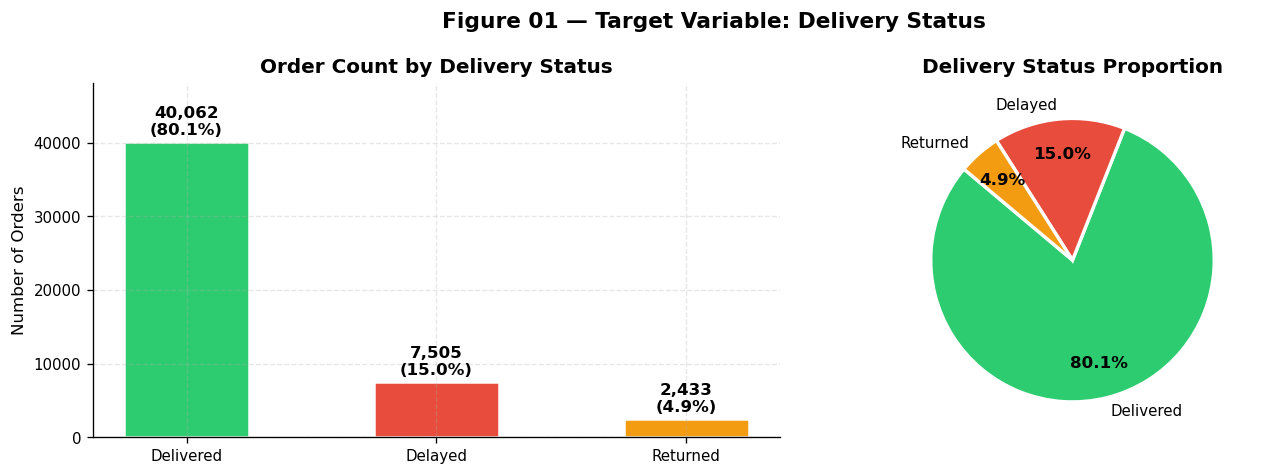

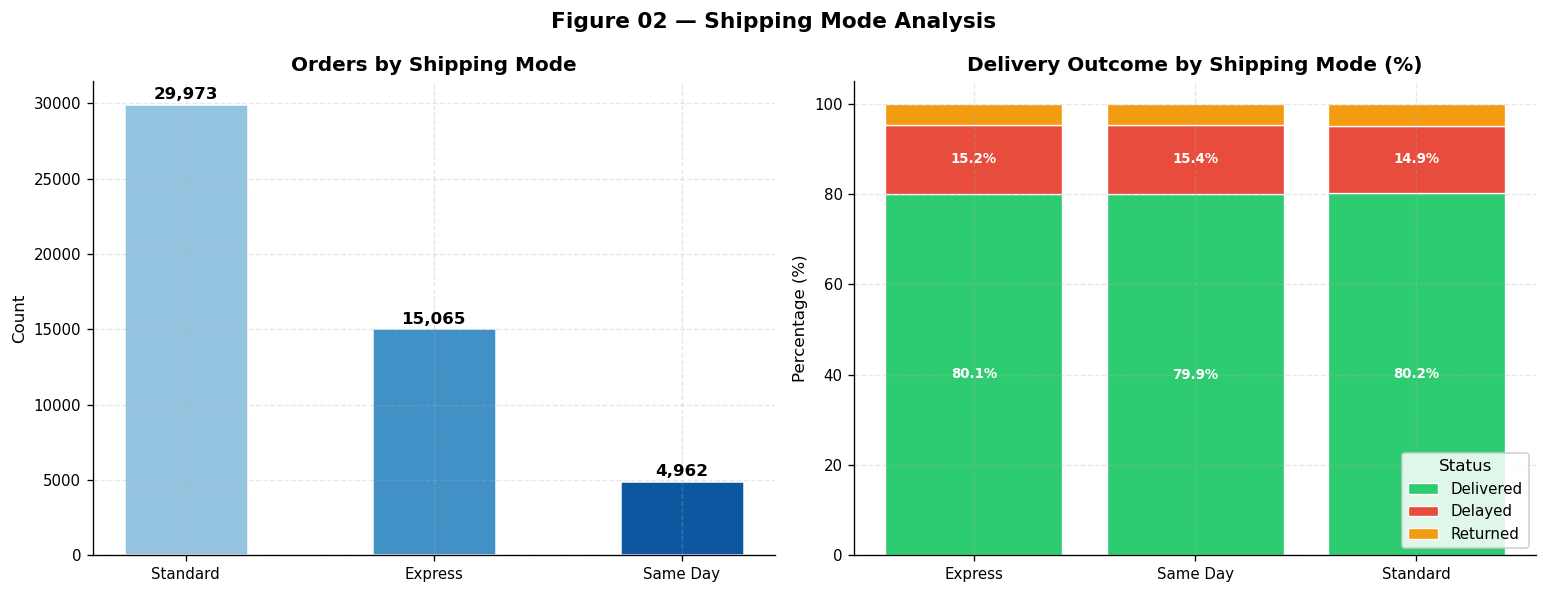

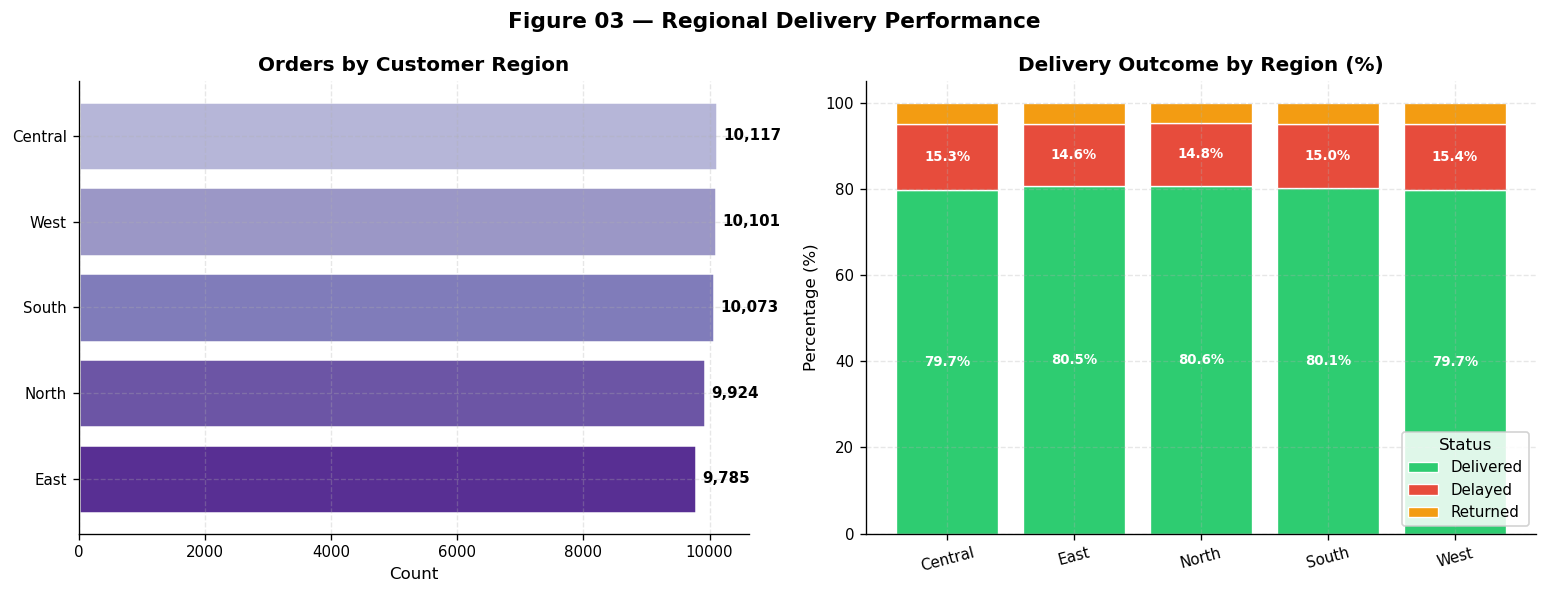

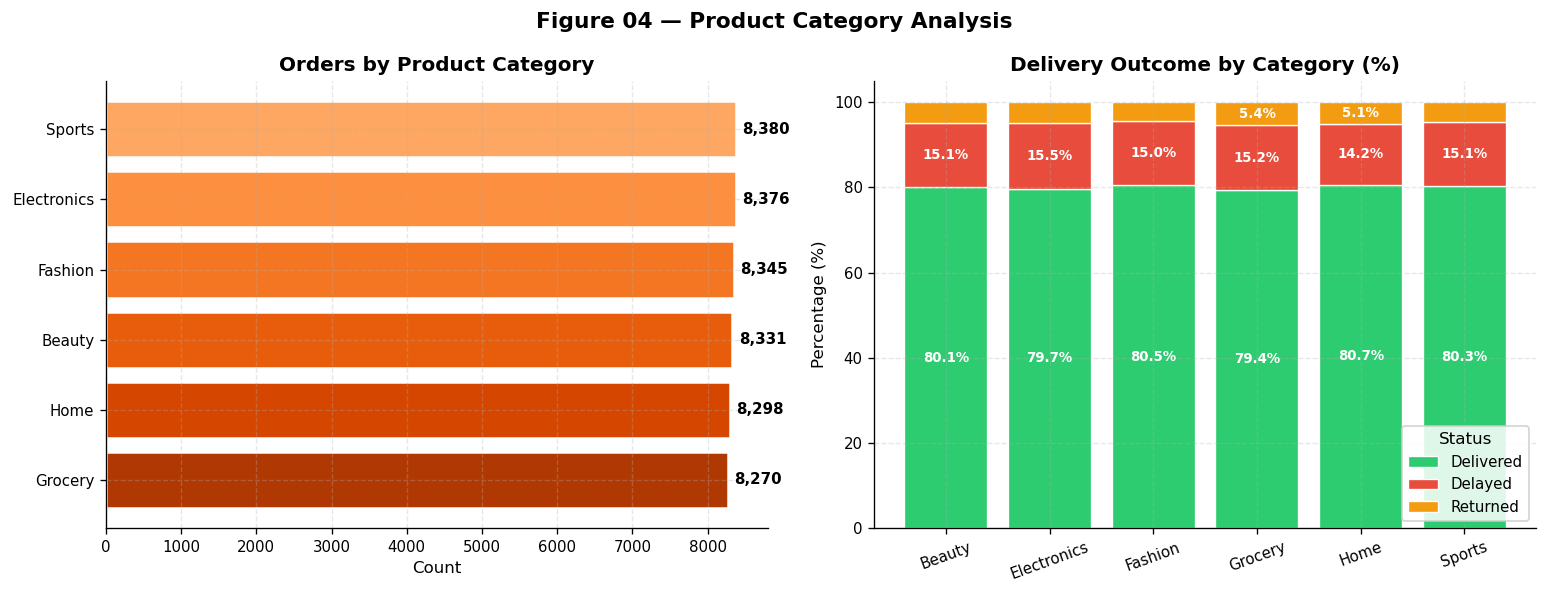

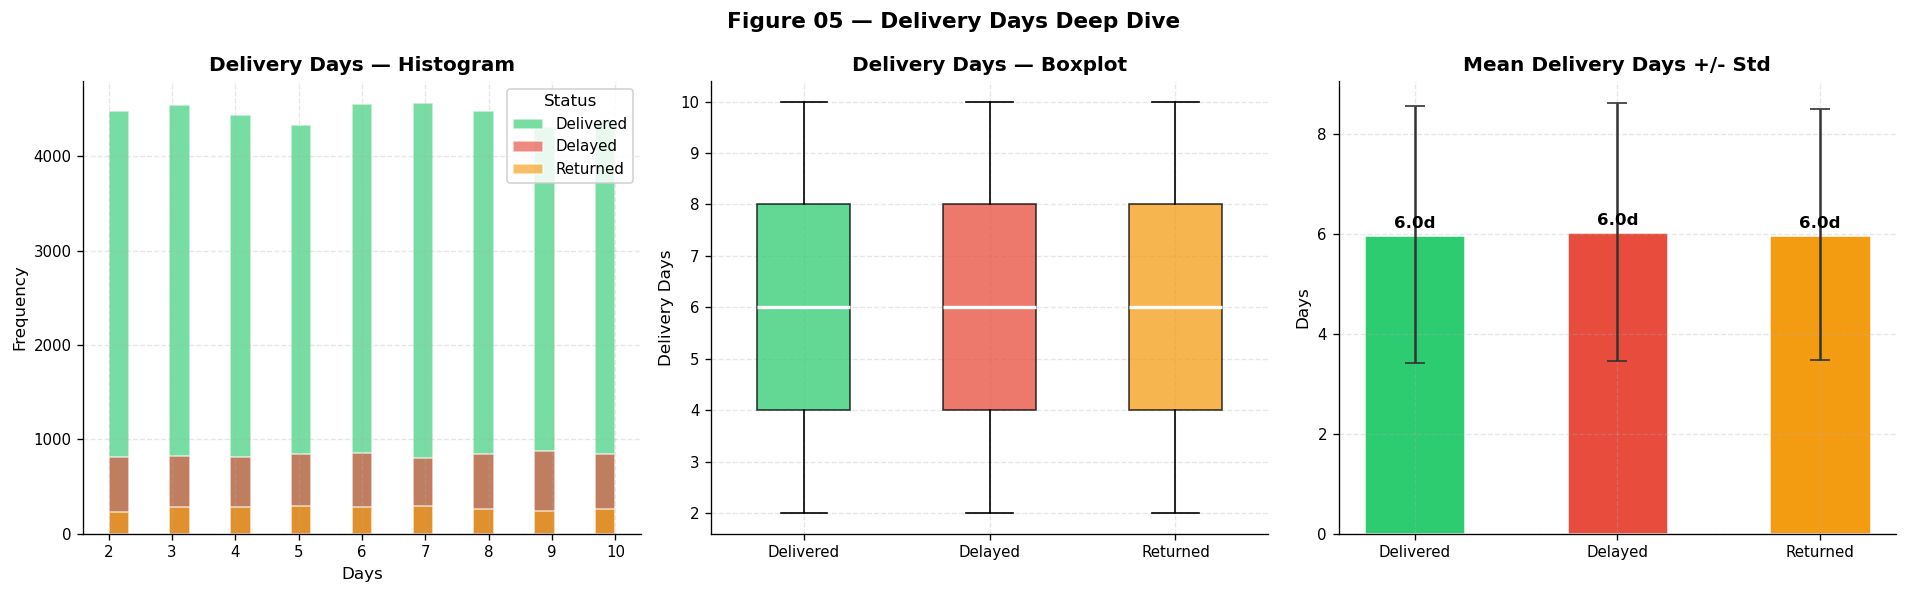

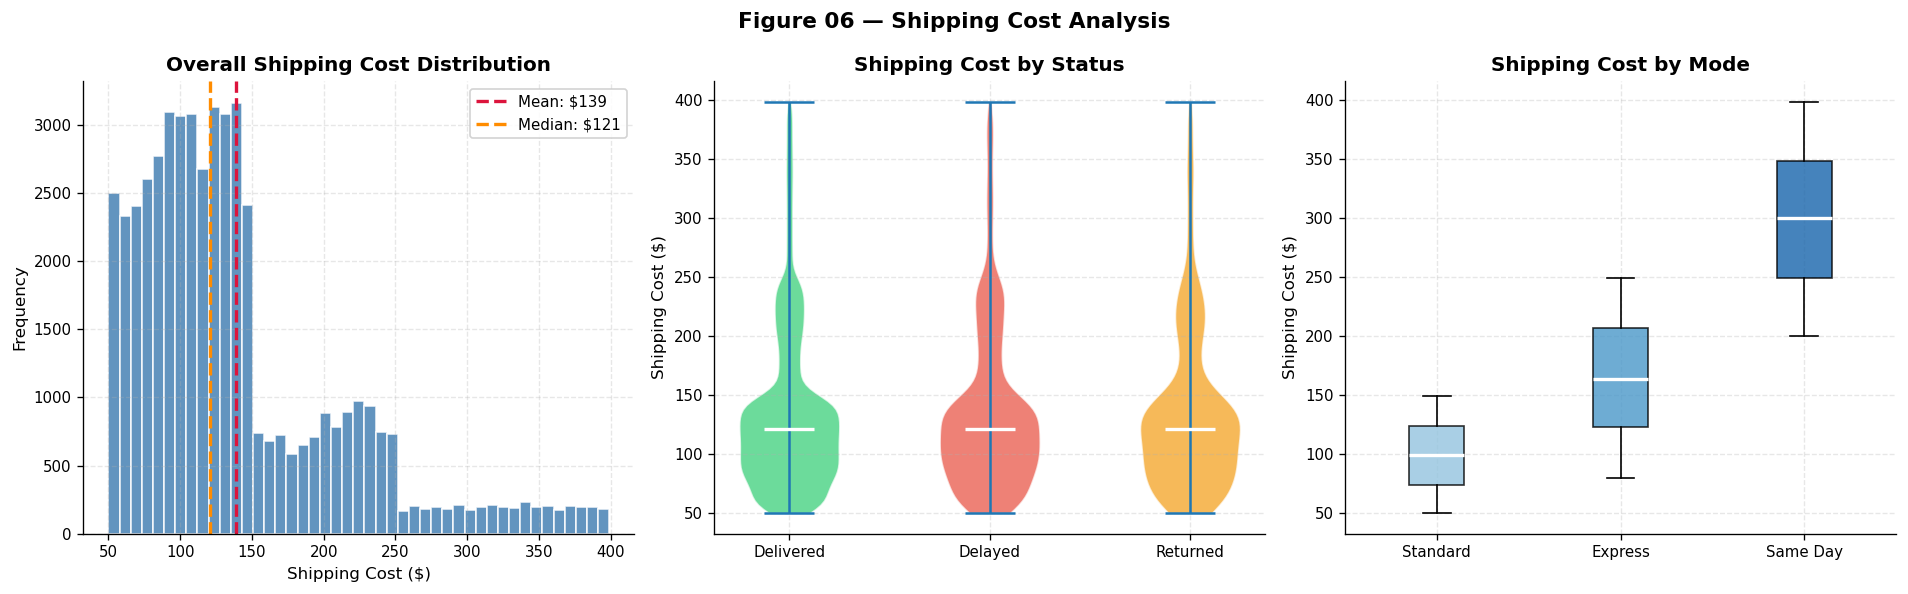

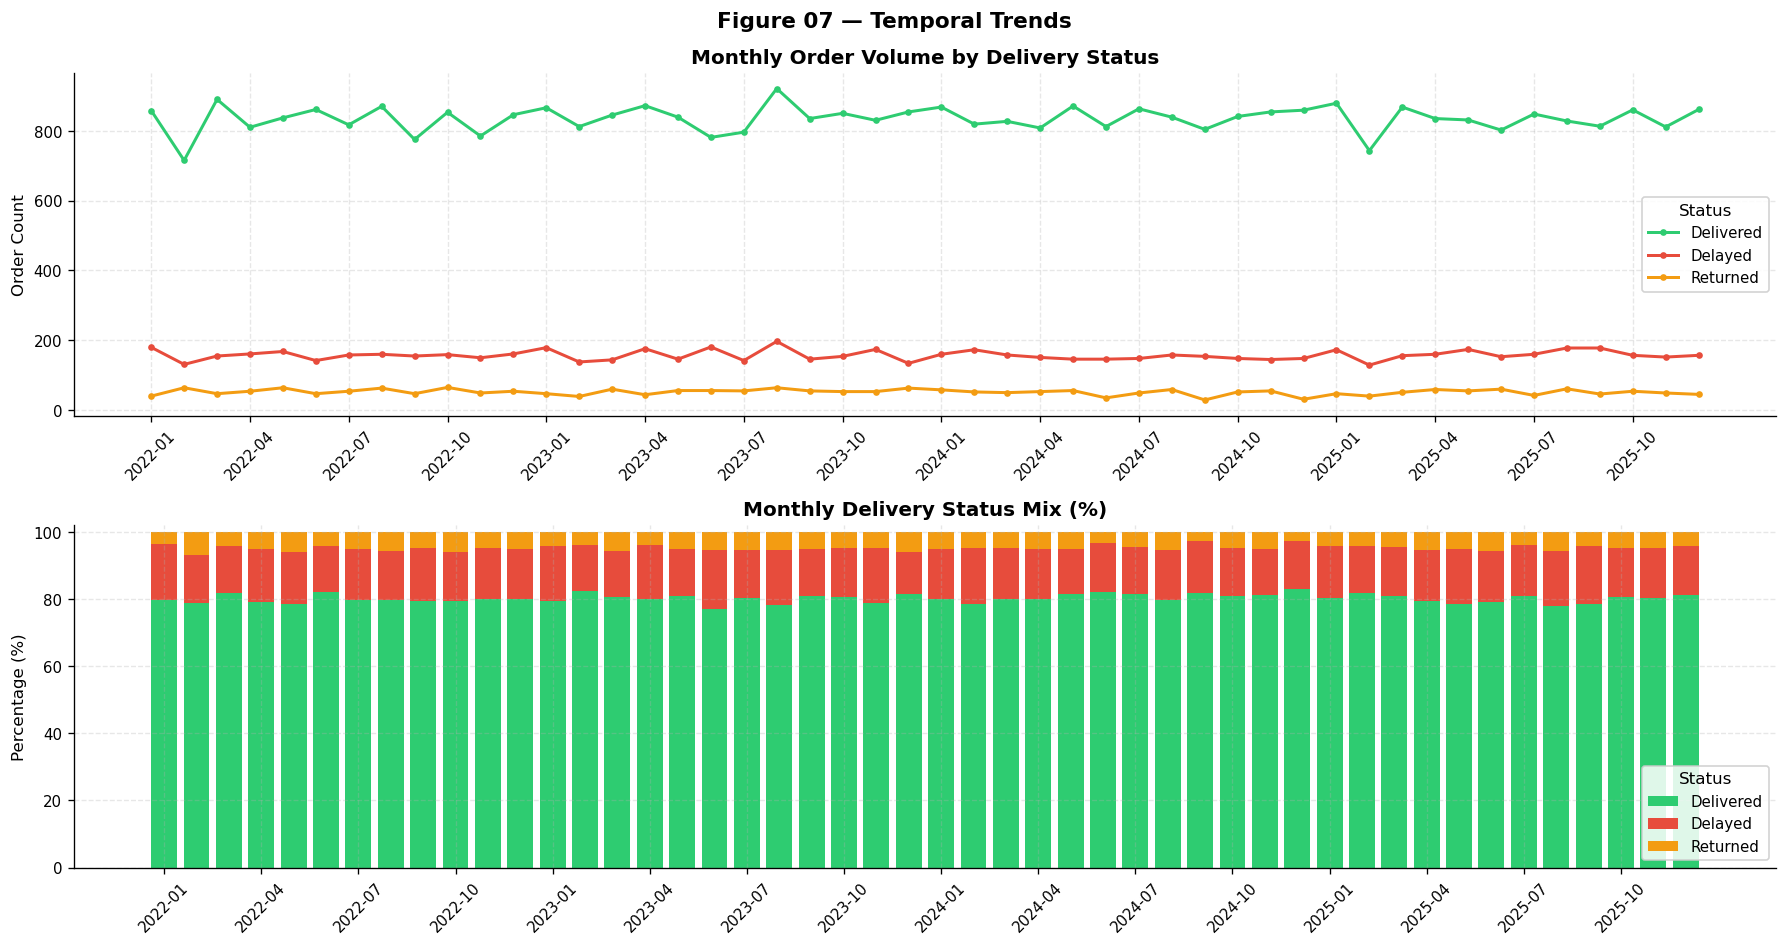

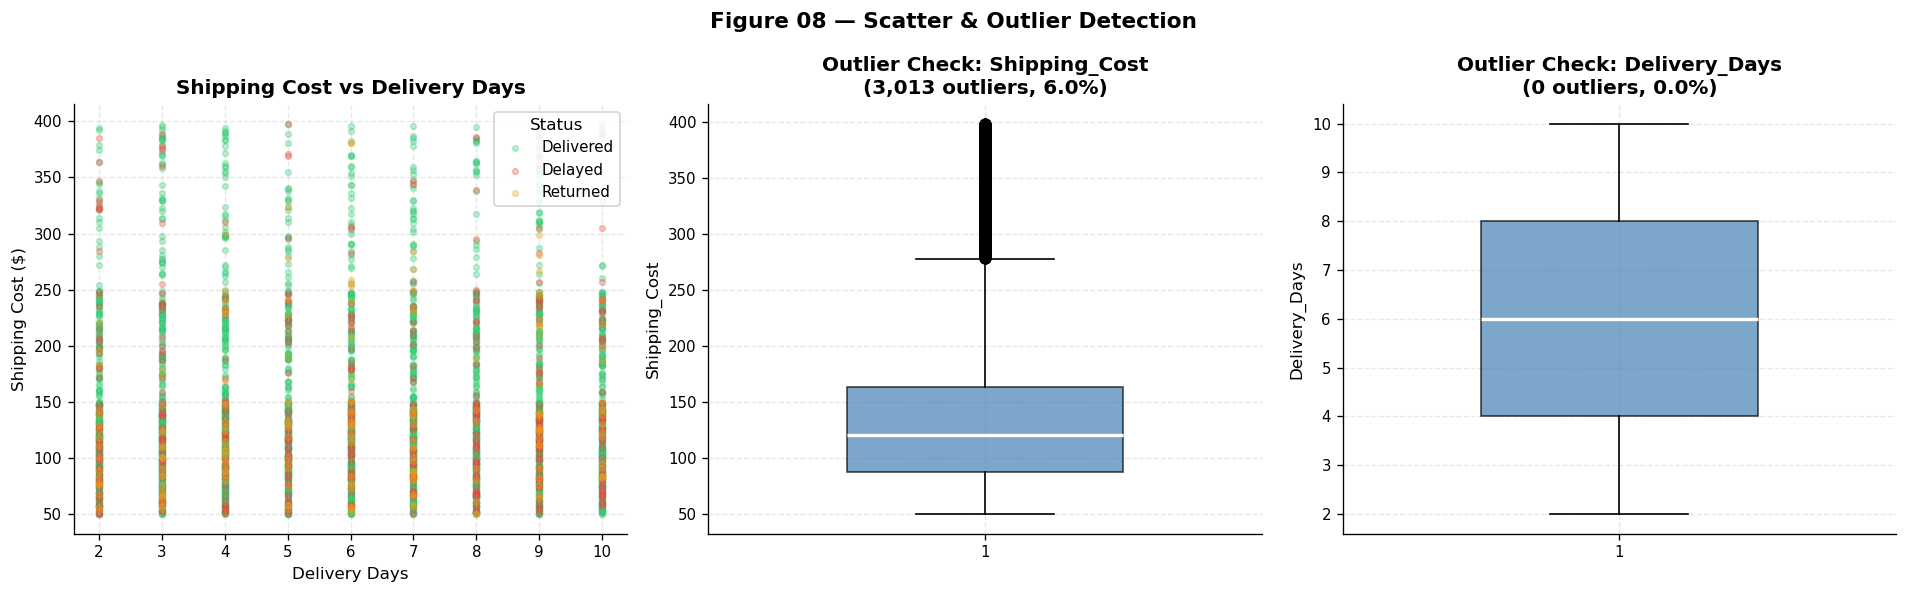

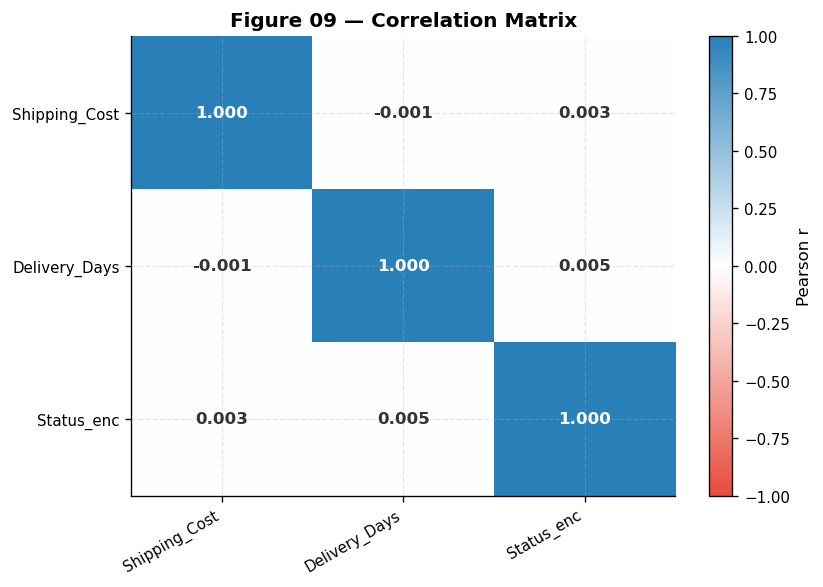


PHASE 2 — PREPROCESSING & FEATURE ENGINEERING
Feature engineering complete.
Total columns now: 32


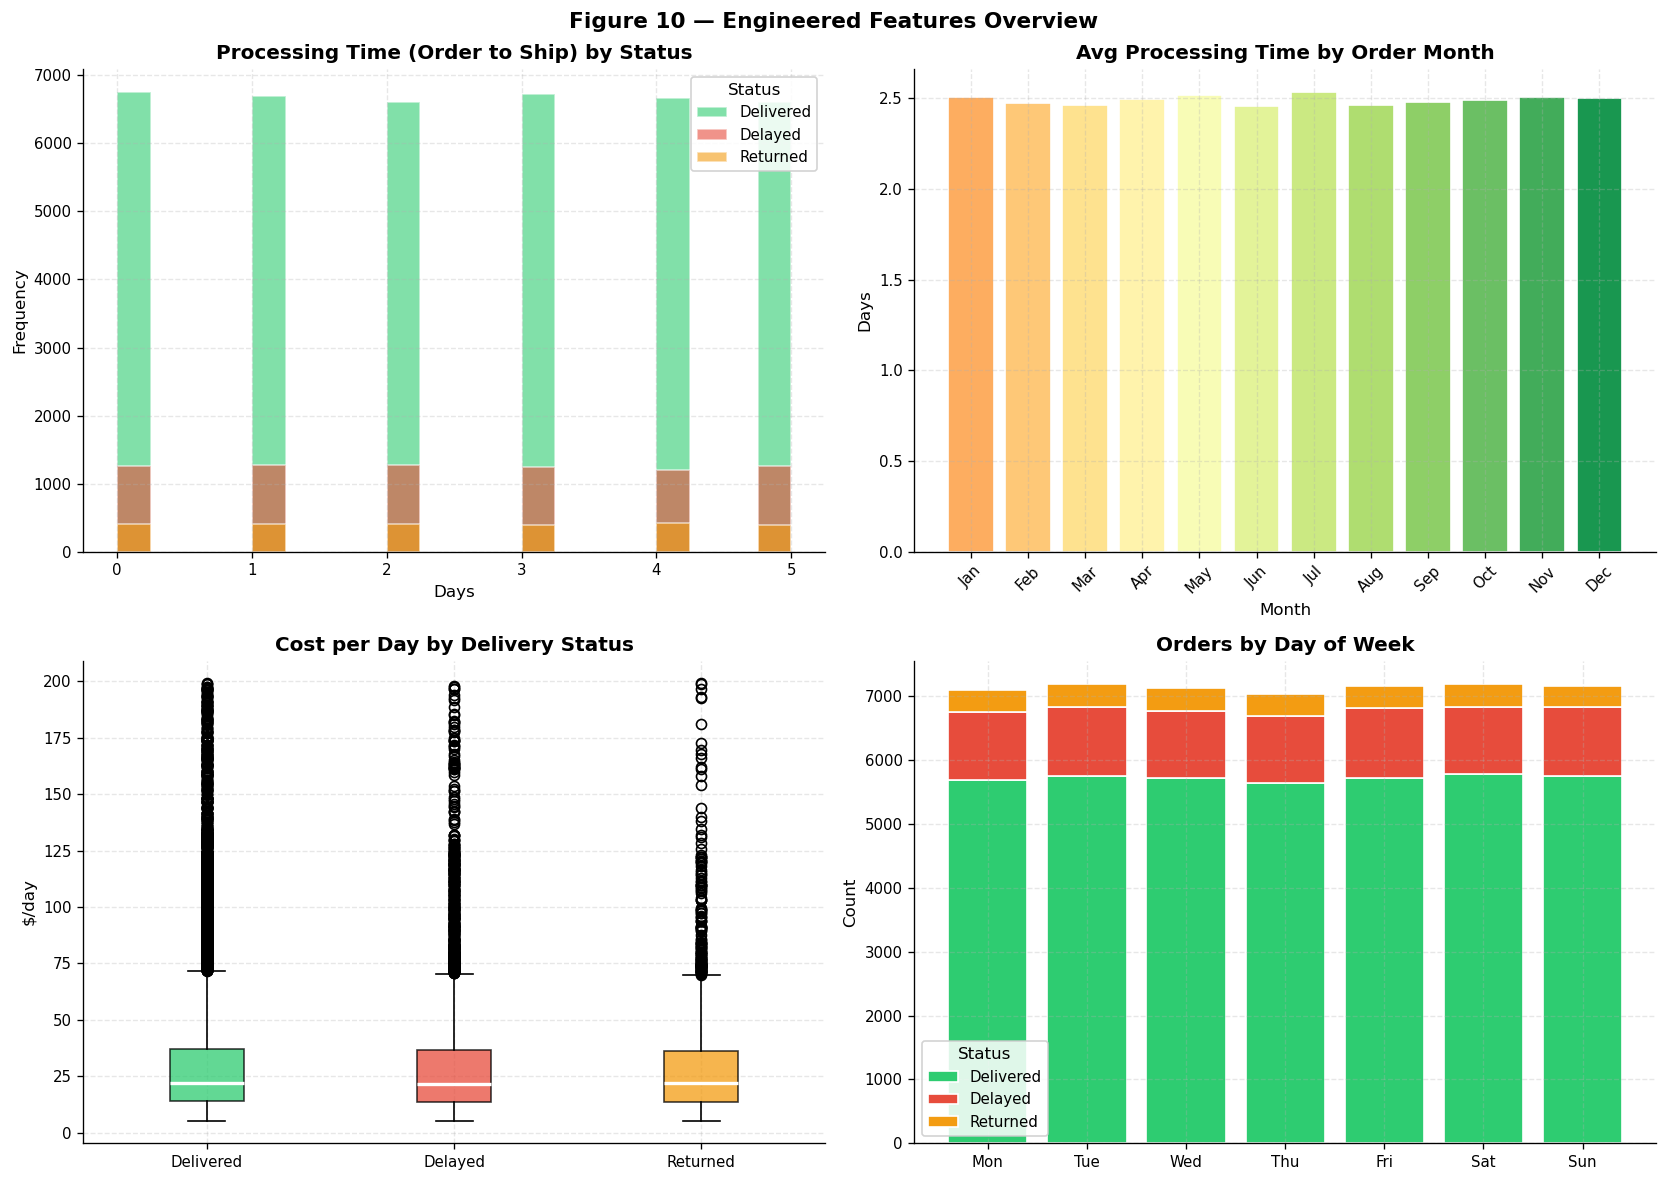


Features  : 27
Train     : 40,000 samples
Test      : 10,000 samples
Target map: {'Delayed': np.int32(0), 'Delivered': np.int32(1), 'Returned': np.int32(2)}
Preprocessed files saved.

PHASE 3 — MODEL TRAINING & EVALUATION
Training Logistic Regression... Acc=0.8012  Prec=0.2671  Rec=0.3333  F1=0.2965
Training Decision Tree... Acc=0.7929  Prec=0.3258  Rec=0.3330  F1=0.3021
Training Random Forest... Acc=0.7989  Prec=0.2855  Rec=0.3326  F1=0.2965
Training Gradient Boosting... Acc=0.8013  Prec=0.4893  Rec=0.3337  F1=0.2974

=== MODEL COMPARISON ===
              Model  Accuracy  Precision  Recall     F1
      Decision Tree    0.7929     0.3258  0.3330 0.3021
  Gradient Boosting    0.8013     0.4893  0.3337 0.2974
Logistic Regression    0.8012     0.2671  0.3333 0.2965
      Random Forest    0.7989     0.2855  0.3326 0.2965


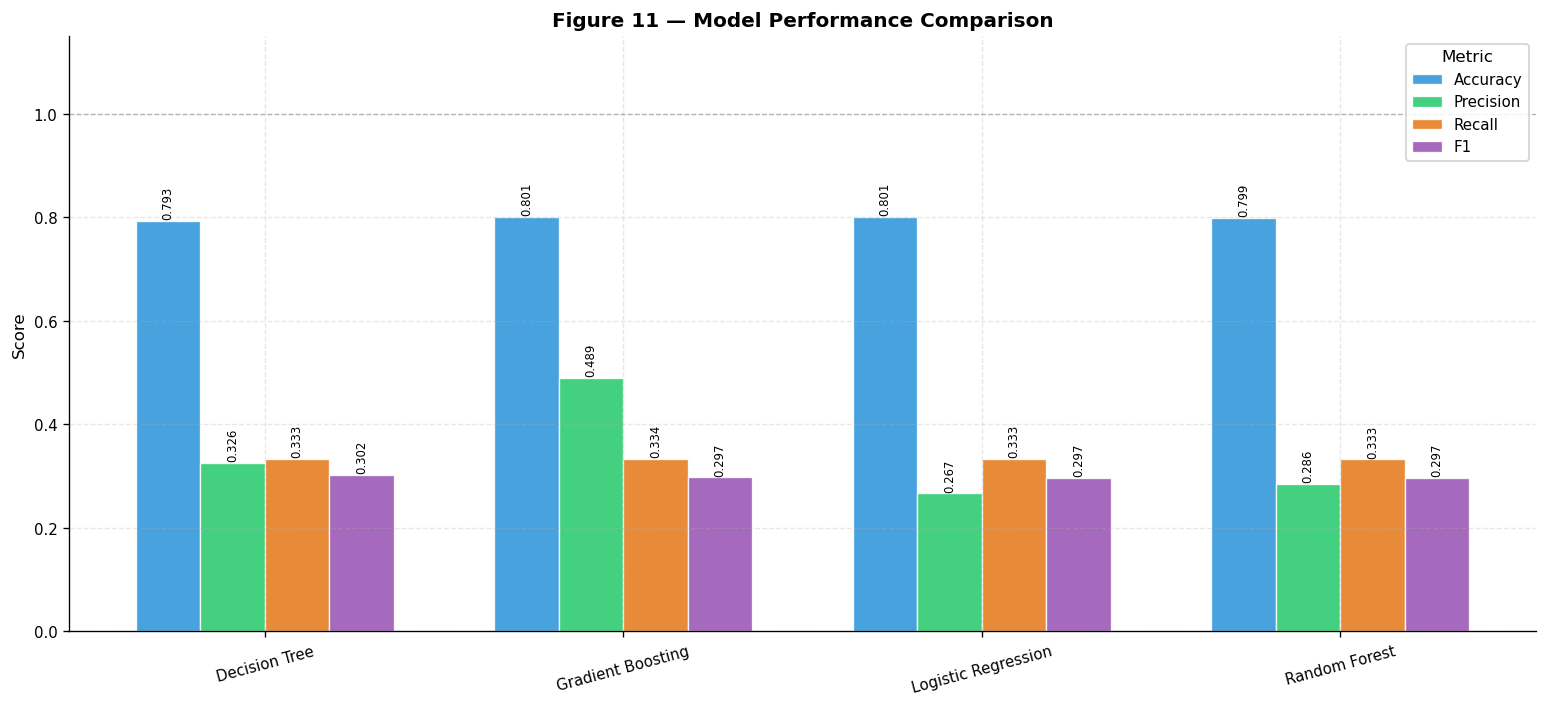

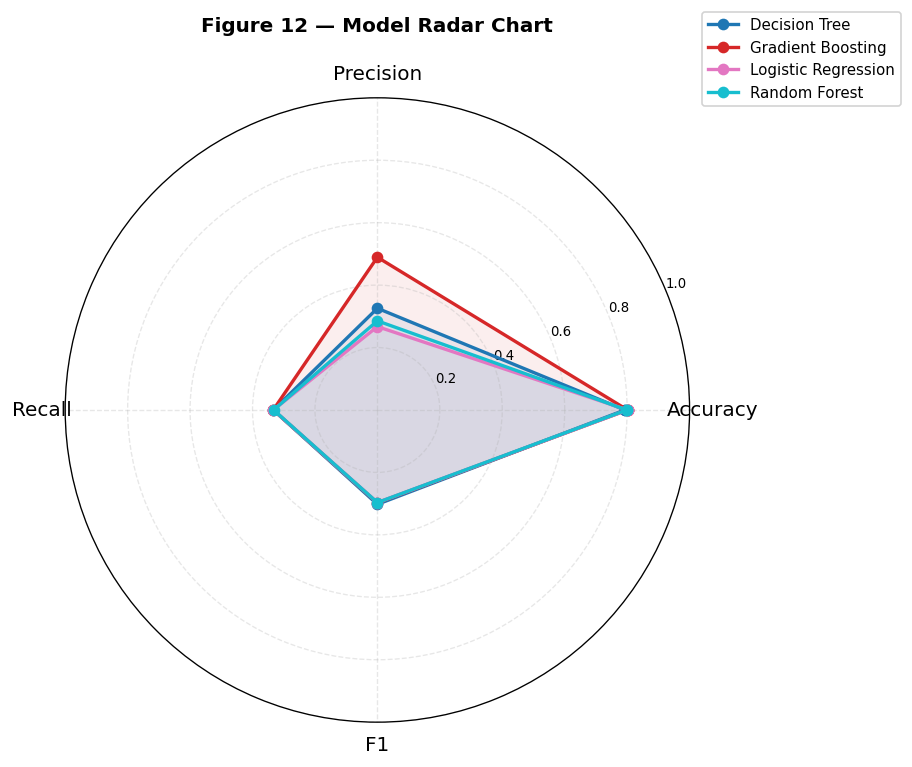


Best Model : Decision Tree
F1 Score   : 0.3021
Accuracy   : 0.7929

=== CLASSIFICATION REPORT (Decision Tree) ===
              precision    recall  f1-score   support

     Delayed       0.14      0.01      0.02      1501
   Delivered       0.80      0.99      0.89      8012
    Returned       0.04      0.00      0.00       487

    accuracy                           0.79     10000
   macro avg       0.33      0.33      0.30     10000
weighted avg       0.66      0.79      0.71     10000



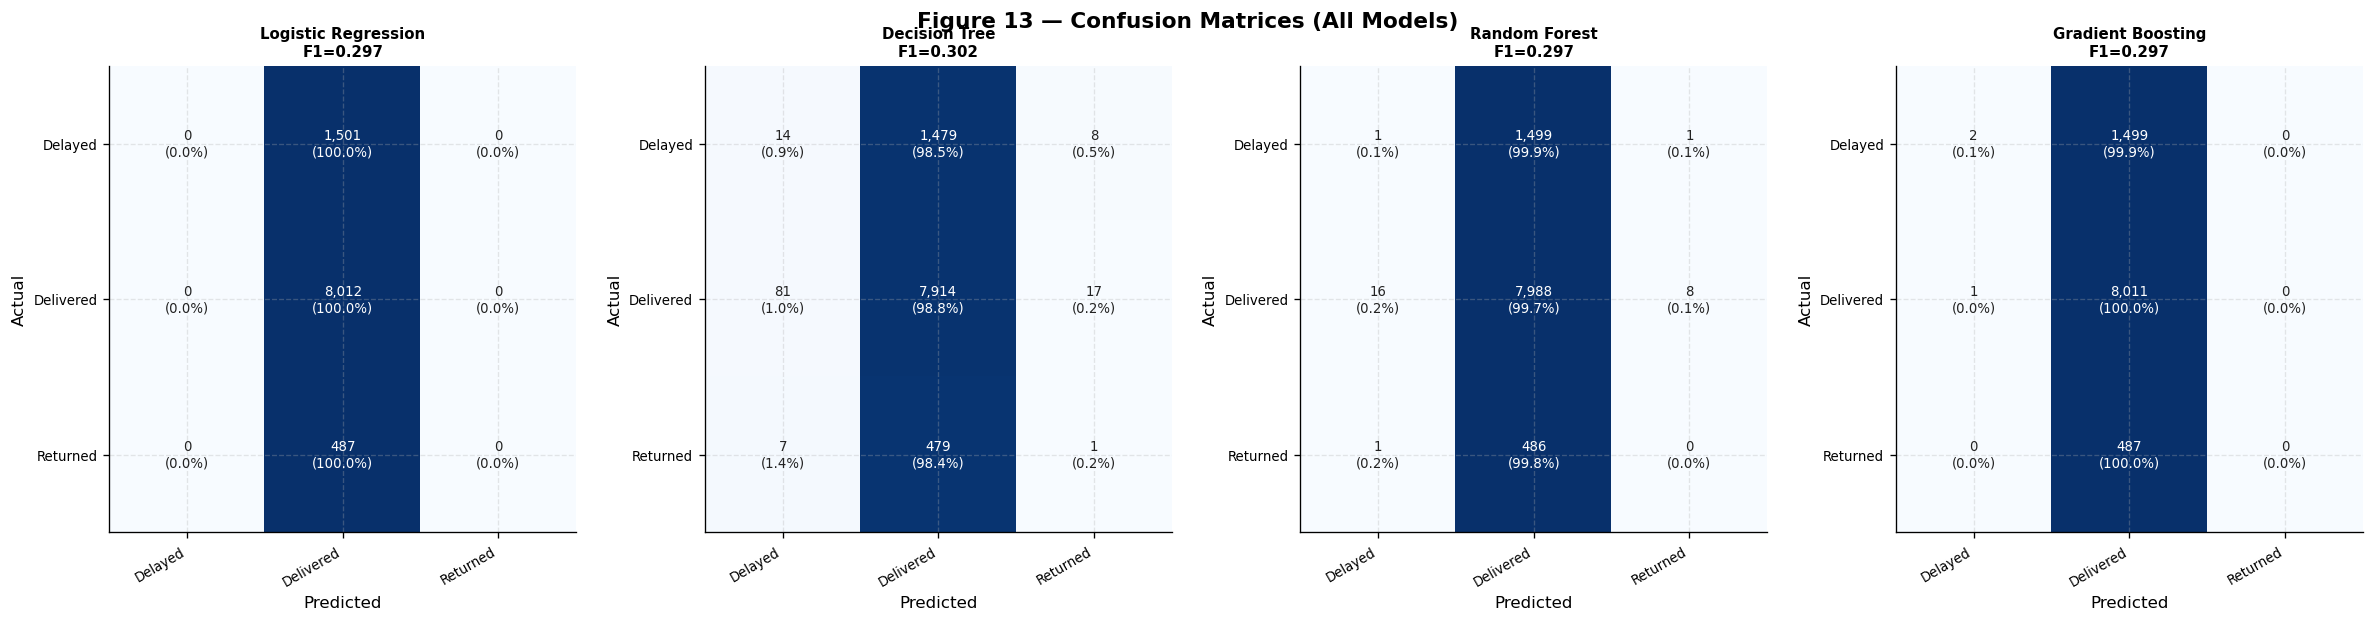

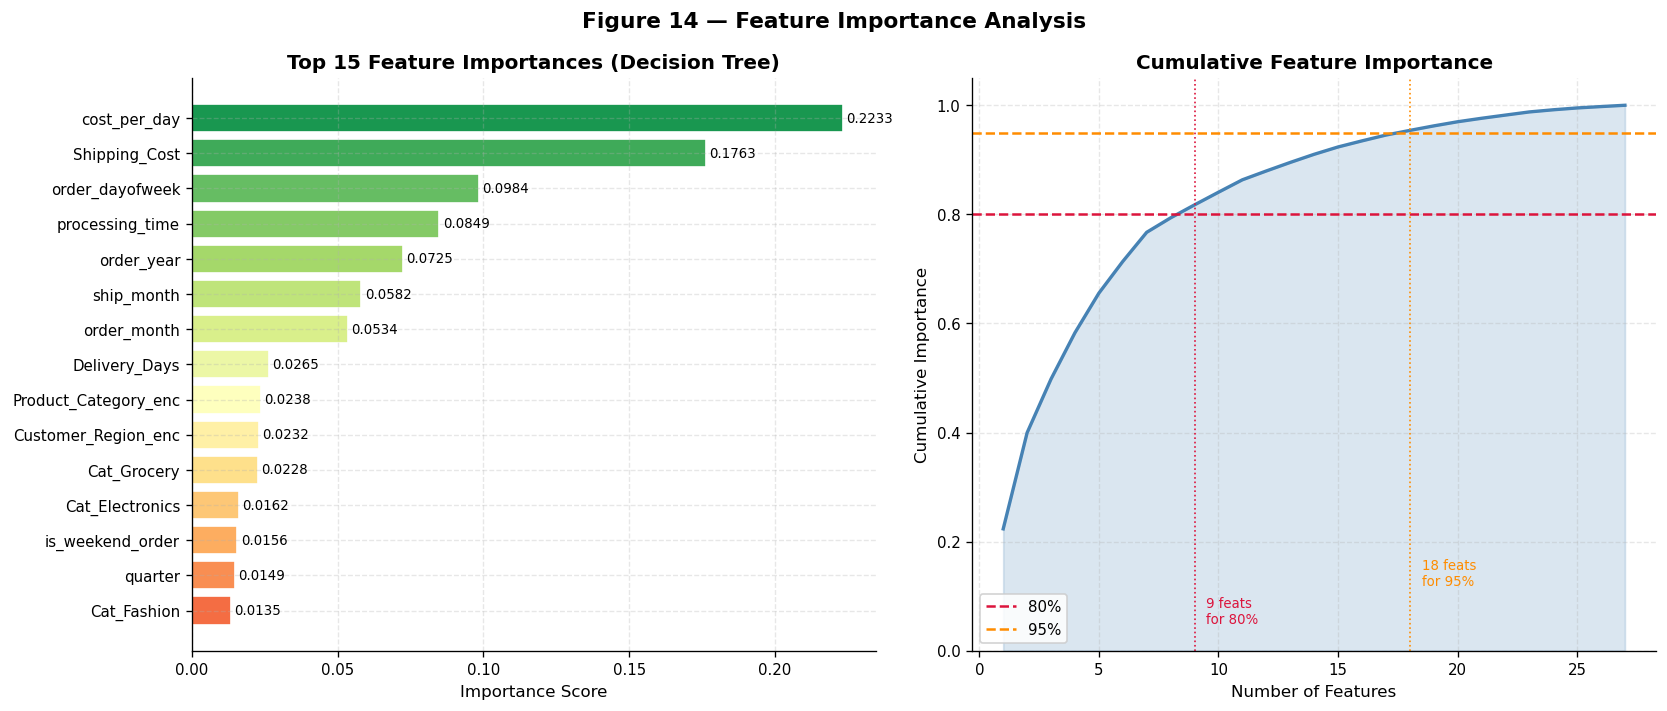

Feature importance saved.


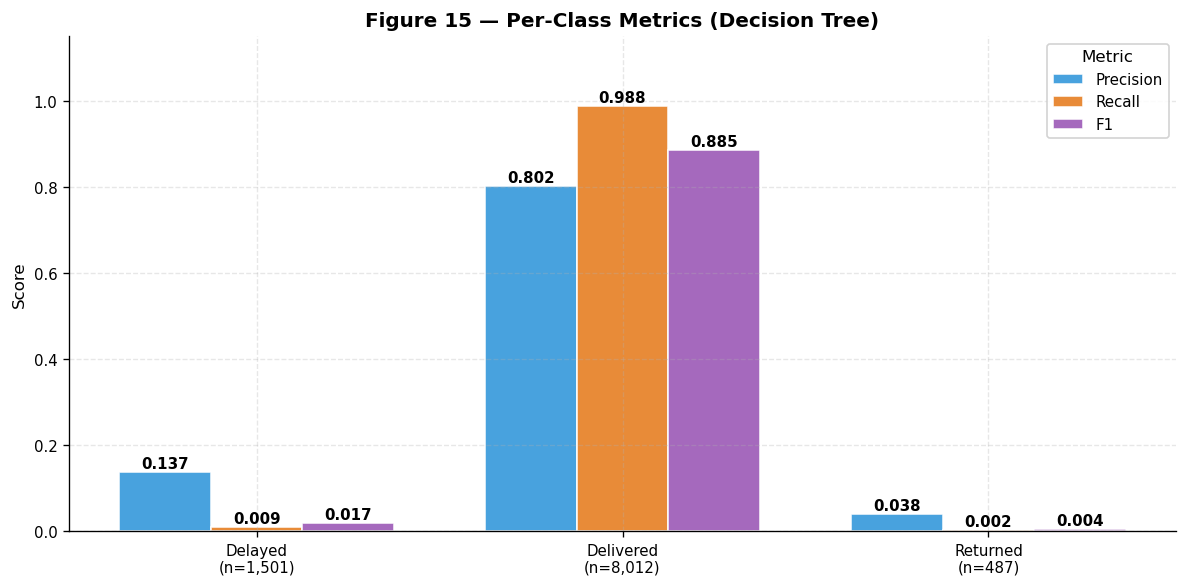

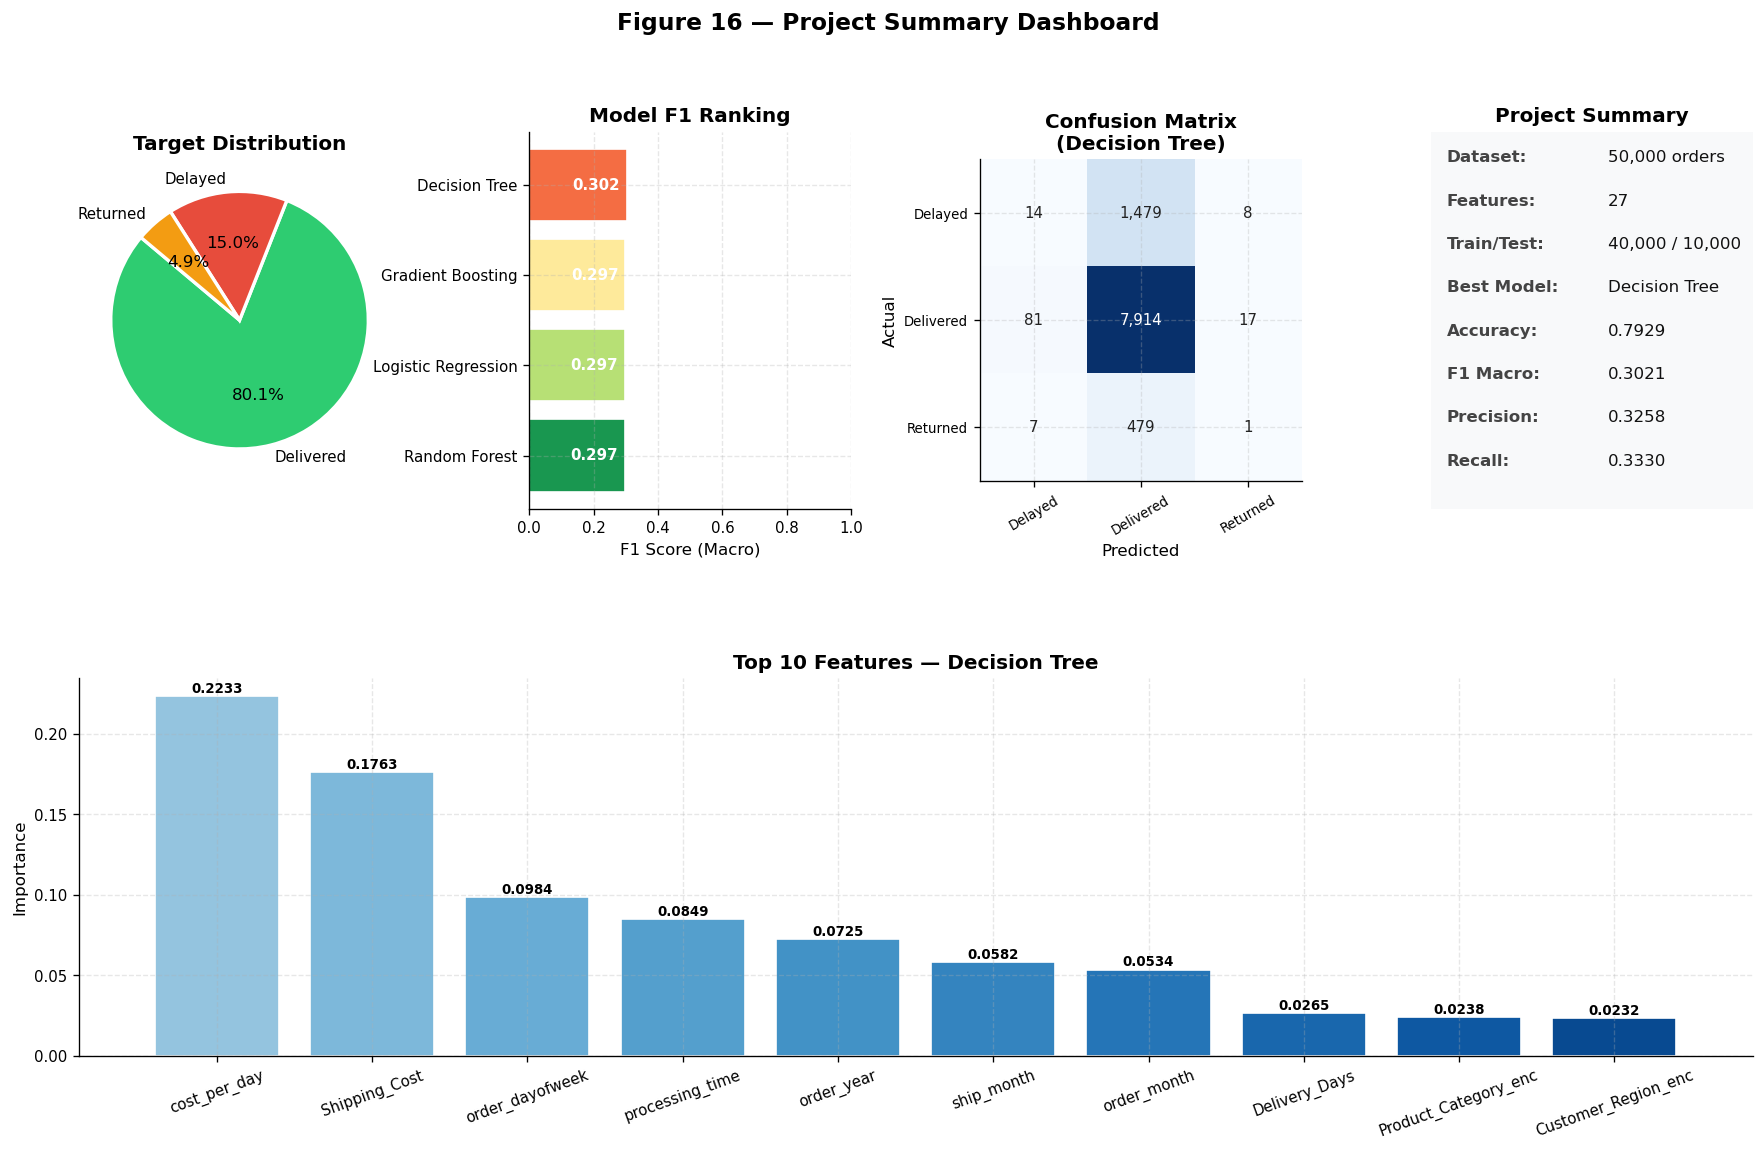


  PROJECT COMPLETE
  Best model : Decision Tree
  Accuracy   : 0.7929
  F1 Macro   : 0.3021
  Figures    : figures/
  Outputs    : outputs/


In [1]:
# ============================================================
# E-COMMERCE DELIVERY PREDICTION
# Authors: Ola Gurthi & Viola Makishti | UNYT Machine Learning
# ============================================================

import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

warnings.filterwarnings('ignore')

# ── Folders ───────────────────────────────────────────────────────────────────
os.makedirs('figures', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.framealpha': 0.85,
})

STATUS_ORDER = ['Delivered', 'Delayed', 'Returned']
PALETTE = {
    'Delivered': '#2ecc71',
    'Delayed': '#e74c3c',
    'Returned': '#f39c12'
}
COLORS = [PALETTE[s] for s in STATUS_ORDER]

def savefig(name):
    plt.savefig(f'figures/{name}.png', bbox_inches='tight', dpi=130)
    plt.show()
    plt.close('all')

print('=' * 60)
print('  E-COMMERCE DELIVERY PREDICTION')
print('  Ola Gurthi & Viola Makishti | UNYT')
print('=' * 60)

# ============================================================
# 1. LOAD DATA
# ============================================================
FILE = 'E-Commerce Order Fulfillment Dataset (50K Records).csv'
df = pd.read_csv(FILE)

print(f'\nShape      : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory     : {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(f'Duplicates : {df.duplicated().sum():,}')
print(f'\nDtypes:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nDescriptive stats:\n{df.describe().round(2)}')

print(f'\nCategorical columns:')
for col in df.select_dtypes(include='object').columns:
    print(f'  {col:25s}: {df[col].nunique():3d} unique → {list(df[col].unique()[:5])}')

print(f'\nFirst 5 rows:\n{df.head()}')

# ============================================================
# 2. EDA
# ============================================================

# ── Fig 01: Target distribution ───────────────────────────────────────────────
counts = df['Delivery_Status'].value_counts().reindex(STATUS_ORDER)
pcts = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(
    STATUS_ORDER,
    counts.values,
    color=COLORS,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

for bar, cnt, pct in zip(bars, counts.values, pcts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.015,
        f'{cnt:,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

axes[0].set_ylim(0, counts.max() * 1.20)
axes[0].set_title('Order Count by Delivery Status')
axes[0].set_ylabel('Number of Orders')

wedges, texts, autotexts = axes[1].pie(
    counts.values,
    labels=STATUS_ORDER,
    colors=COLORS,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')

axes[1].set_title('Delivery Status Proportion')

plt.suptitle('Figure 01 — Target Variable: Delivery Status', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('fig01_target_distribution')

# ── Fig 02: Shipping mode ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mode_counts = df['Shipping_Mode'].value_counts()
mode_colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(mode_counts)))

bars = axes[0].bar(
    mode_counts.index,
    mode_counts.values,
    color=mode_colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

for bar, v in zip(bars, mode_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + mode_counts.max() * 0.01,
        f'{v:,}',
        ha='center',
        fontweight='bold',
        fontsize=10
    )

axes[0].set_title('Orders by Shipping Mode')
axes[0].set_ylabel('Count')

cross = pd.crosstab(
    df['Shipping_Mode'],
    df['Delivery_Status'],
    normalize='index'
) * 100
cross = cross.reindex(columns=STATUS_ORDER, fill_value=0)

bottom = np.zeros(len(cross))
for status, color in zip(STATUS_ORDER, COLORS):
    vals = cross[status].values
    axes[1].bar(
        cross.index,
        vals,
        bottom=bottom,
        label=status,
        color=color,
        edgecolor='white',
        linewidth=0.8
    )
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            axes[1].text(
                i,
                b + v / 2,
                f'{v:.1f}%',
                ha='center',
                va='center',
                fontsize=8,
                fontweight='bold',
                color='white'
            )
    bottom += vals

axes[1].set_title('Delivery Outcome by Shipping Mode (%)')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Status', loc='lower right')
axes[1].set_ylim(0, 105)

plt.suptitle('Figure 02 — Shipping Mode Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('fig02_shipping_mode')

# ── Fig 03: Customer region ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

region_counts = df['Customer_Region'].value_counts()
reg_colors = plt.cm.Purples(np.linspace(0.4, 0.85, len(region_counts)))

bars = axes[0].barh(
    region_counts.index,
    region_counts.values,
    color=reg_colors,
    edgecolor='white',
    linewidth=1.5
)

for bar, v in zip(bars, region_counts.values):
    axes[0].text(
        bar.get_width() + region_counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{v:,}',
        va='center',
        fontweight='bold',
        fontsize=9
    )

axes[0].set_title('Orders by Customer Region')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

cross_r = pd.crosstab(
    df['Customer_Region'],
    df['Delivery_Status'],
    normalize='index'
) * 100
cross_r = cross_r.reindex(columns=STATUS_ORDER, fill_value=0)

bottom = np.zeros(len(cross_r))
for status, color in zip(STATUS_ORDER, COLORS):
    vals = cross_r[status].values
    axes[1].bar(
        cross_r.index,
        vals,
        bottom=bottom,
        label=status,
        color=color,
        edgecolor='white',
        linewidth=0.8
    )
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            axes[1].text(
                i,
                b + v / 2,
                f'{v:.1f}%',
                ha='center',
                va='center',
                fontsize=8,
                fontweight='bold',
                color='white'
            )
    bottom += vals

axes[1].set_title('Delivery Outcome by Region (%)')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Status', loc='lower right')
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Figure 03 — Regional Delivery Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('fig03_region_analysis')

# ── Fig 04: Product category ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cat_counts = df['Product_Category'].value_counts()
cat_colors = plt.cm.Oranges(np.linspace(0.4, 0.85, len(cat_counts)))

bars = axes[0].barh(
    cat_counts.index,
    cat_counts.values,
    color=cat_colors,
    edgecolor='white',
    linewidth=1.5
)

for bar, v in zip(bars, cat_counts.values):
    axes[0].text(
        bar.get_width() + cat_counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{v:,}',
        va='center',
        fontweight='bold',
        fontsize=9
    )

axes[0].set_title('Orders by Product Category')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

cross_c = pd.crosstab(
    df['Product_Category'],
    df['Delivery_Status'],
    normalize='index'
) * 100
cross_c = cross_c.reindex(columns=STATUS_ORDER, fill_value=0)

bottom = np.zeros(len(cross_c))
for status, color in zip(STATUS_ORDER, COLORS):
    vals = cross_c[status].values
    axes[1].bar(
        cross_c.index,
        vals,
        bottom=bottom,
        label=status,
        color=color,
        edgecolor='white',
        linewidth=0.8
    )
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            axes[1].text(
                i,
                b + v / 2,
                f'{v:.1f}%',
                ha='center',
                va='center',
                fontsize=8,
                fontweight='bold',
                color='white'
            )
    bottom += vals

axes[1].set_title('Delivery Outcome by Category (%)')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Status', loc='lower right')
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Figure 04 — Product Category Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('fig04_category_analysis')

# ── Fig 05: Delivery days ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for status, color in PALETTE.items():
    axes[0].hist(
        df[df['Delivery_Status'] == status]['Delivery_Days'],
        bins=25,
        alpha=0.65,
        label=status,
        color=color,
        edgecolor='white'
    )

axes[0].set_title('Delivery Days — Histogram')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Frequency')
axes[0].legend(title='Status')

bp = axes[1].boxplot(
    [df[df['Delivery_Status'] == s]['Delivery_Days'] for s in STATUS_ORDER],
    labels=STATUS_ORDER,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2)
)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

axes[1].set_title('Delivery Days — Boxplot')
axes[1].set_ylabel('Delivery Days')

means = [df[df['Delivery_Status'] == s]['Delivery_Days'].mean() for s in STATUS_ORDER]
stds = [df[df['Delivery_Status'] == s]['Delivery_Days'].std() for s in STATUS_ORDER]

bars = axes[2].bar(
    STATUS_ORDER,
    means,
    color=COLORS,
    edgecolor='white',
    linewidth=1.5,
    width=0.5,
    yerr=stds,
    capsize=6,
    error_kw=dict(ecolor='#333', linewidth=1.5)
)
for bar, m in zip(bars, means):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(stds) * 0.05,
        f'{m:.1f}d',
        ha='center',
        fontweight='bold',
        fontsize=10
    )

axes[2].set_title('Mean Delivery Days +/- Std')
axes[2].set_ylabel('Days')

plt.suptitle('Figure 05 — Delivery Days Deep Dive', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('fig05_delivery_days')

# ── Fig 06: Shipping cost ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(
    df['Shipping_Cost'],
    bins=45,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)
axes[0].axvline(
    df['Shipping_Cost'].mean(),
    color='crimson',
    linestyle='--',
    lw=2,
    label=f"Mean: ${df['Shipping_Cost'].mean():.0f}"
)
axes[0].axvline(
    df['Shipping_Cost'].median(),
    color='darkorange',
    linestyle='--',
    lw=2,
    label=f"Median: ${df['Shipping_Cost'].median():.0f}"
)
axes[0].set_title('Overall Shipping Cost Distribution')
axes[0].set_xlabel('Shipping Cost ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

plot_data = [df[df['Delivery_Status'] == s]['Shipping_Cost'] for s in STATUS_ORDER]
parts = axes[1].violinplot(plot_data, showmedians=True)

for pc, color in zip(parts['bodies'], COLORS):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('white')

parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2)

axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(STATUS_ORDER)
axes[1].set_title('Shipping Cost by Status')
axes[1].set_ylabel('Shipping Cost ($)')

mode_list = list(df['Shipping_Mode'].unique())
mode_data = [df[df['Shipping_Mode'] == m]['Shipping_Cost'] for m in mode_list]
mode_col = plt.cm.Blues(np.linspace(0.4, 0.8, len(mode_list)))

bp2 = axes[2].boxplot(
    mode_data,
    labels=mode_list,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)
for patch, c in zip(bp2['boxes'], mode_col):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)

axes[2].set_title('Shipping Cost by Mode')
axes[2].set_ylabel('Shipping Cost ($)')

plt.suptitle('Figure 06 — Shipping Cost Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('fig06_shipping_cost')

# ── Fig 07: Temporal trend ────────────────────────────────────────────────────
df['Order_Date_dt'] = pd.to_datetime(df['Order_Date'])
df['YearMonth'] = df['Order_Date_dt'].dt.to_period('M')

monthly = df.groupby(['YearMonth', 'Delivery_Status']).size().unstack(fill_value=0)
monthly.index = monthly.index.astype(str)

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

for status, color in PALETTE.items():
    if status in monthly.columns:
        axes[0].plot(
            monthly.index,
            monthly[status],
            marker='o',
            markersize=3,
            label=status,
            color=color,
            linewidth=1.8
        )

axes[0].set_title('Monthly Order Volume by Delivery Status')
axes[0].set_ylabel('Order Count')
axes[0].legend(title='Status')

tick_pos = list(range(0, len(monthly.index), 3))
axes[0].set_xticks(tick_pos)
axes[0].set_xticklabels([monthly.index[i] for i in tick_pos], rotation=45)

monthly_total = monthly.sum(axis=1)
monthly_pct = monthly.div(monthly_total, axis=0) * 100

bottom = np.zeros(len(monthly_pct))
for status, color in zip(STATUS_ORDER, COLORS):
    if status in monthly_pct.columns:
        vals = monthly_pct[status].values
        axes[1].bar(
            monthly_pct.index,
            vals,
            bottom=bottom,
            color=color,
            label=status,
            edgecolor='none'
        )
        bottom += vals

axes[1].set_xticks(tick_pos)
axes[1].set_xticklabels([monthly_pct.index[i] for i in tick_pos], rotation=45)
axes[1].set_title('Monthly Delivery Status Mix (%)')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Status', loc='lower right')
axes[1].set_ylim(0, 102)

plt.suptitle('Figure 07 — Temporal Trends', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('fig07_temporal')

# ── Fig 08: Scatter + outlier detection ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sample = df.sample(4000, random_state=42)

for status, color in PALETTE.items():
    sub = sample[sample['Delivery_Status'] == status]
    axes[0].scatter(
        sub['Delivery_Days'],
        sub['Shipping_Cost'],
        alpha=0.3,
        label=status,
        color=color,
        s=12
    )

axes[0].set_title('Shipping Cost vs Delivery Days')
axes[0].set_xlabel('Delivery Days')
axes[0].set_ylabel('Shipping Cost ($)')
axes[0].legend(title='Status')

for ax, col in zip([axes[1], axes[2]], ['Shipping_Cost', 'Delivery_Days']):
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    pct_out = n_out / len(df) * 100

    bp = ax.boxplot(
        df[col],
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='white', linewidth=2)
    )
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.7)

    ax.set_title(f'Outlier Check: {col}\n({n_out:,} outliers, {pct_out:.1f}%)')
    ax.set_ylabel(col)

plt.suptitle('Figure 08 — Scatter & Outlier Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('fig08_scatter_outliers')

# ── Fig 09: Correlation matrix ────────────────────────────────────────────────
num_df = df[['Shipping_Cost', 'Delivery_Days']].copy()
num_df['Status_enc'] = df['Delivery_Status'].map({
    'Delivered': 0,
    'Delayed': 1,
    'Returned': 2
})
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(7, 5))
cmap = LinearSegmentedColormap.from_list('rw', ['#e74c3c', 'white', '#2980b9'])
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=30, ha='right')
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        v = corr.iloc[i, j]
        ax.text(
            j,
            i,
            f'{v:.3f}',
            ha='center',
            va='center',
            fontsize=10,
            fontweight='bold',
            color='white' if abs(v) > 0.4 else '#333'
        )

plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('Figure 09 — Correlation Matrix', fontweight='bold')
plt.tight_layout()
savefig('fig09_correlation')

# ============================================================
# 3. PREPROCESSING & FEATURE ENGINEERING
# ============================================================
print('\n' + '=' * 60)
print('PHASE 2 — PREPROCESSING & FEATURE ENGINEERING')
print('=' * 60)

df_proc = df.copy()

for col in ['Order_Date', 'Ship_Date', 'Delivery_Date']:
    df_proc[col] = pd.to_datetime(df_proc[col])

if 'Order_ID' in df_proc.columns:
    df_proc.drop(columns=['Order_ID'], inplace=True)

# Date features
df_proc['processing_time'] = (df_proc['Ship_Date'] - df_proc['Order_Date']).dt.days
df_proc['order_month'] = df_proc['Order_Date'].dt.month
df_proc['order_dayofweek'] = df_proc['Order_Date'].dt.dayofweek
df_proc['order_year'] = df_proc['Order_Date'].dt.year
df_proc['ship_month'] = df_proc['Ship_Date'].dt.month
df_proc['is_weekend_order'] = (df_proc['order_dayofweek'] >= 5).astype(int)
df_proc['quarter'] = df_proc['Order_Date'].dt.quarter

# Shipping flags
df_proc['is_express'] = (df_proc['Shipping_Mode'] == 'Express').astype(int)
df_proc['is_same_day'] = (df_proc['Shipping_Mode'] == 'Same Day').astype(int)
df_proc['is_standard'] = (df_proc['Shipping_Mode'] == 'Standard').astype(int)

# Cost efficiency
df_proc['cost_per_day'] = (
    df_proc['Shipping_Cost'] /
    df_proc['Delivery_Days'].replace(0, np.nan)
).fillna(0).round(3)

# Encode categoricals
cat_features = ['Customer_Region', 'Product_Category', 'Shipping_Mode']
le_dict = {}

for col in cat_features:
    le = LabelEncoder()
    df_proc[col + '_enc'] = le.fit_transform(df_proc[col])
    le_dict[col] = le

region_dummies = pd.get_dummies(df_proc['Customer_Region'], prefix='Region')
category_dummies = pd.get_dummies(df_proc['Product_Category'], prefix='Cat')
df_proc = pd.concat([df_proc, region_dummies, category_dummies], axis=1)

le_target = LabelEncoder()
df_proc['target'] = le_target.fit_transform(df_proc['Delivery_Status'])

drop_cols = ['Order_Date', 'Ship_Date', 'Delivery_Date', 'Order_Date_dt', 'YearMonth']
df_proc.drop(
    columns=[c for c in drop_cols if c in df_proc.columns],
    errors='ignore',
    inplace=True
)

print('Feature engineering complete.')
print(f'Total columns now: {df_proc.shape[1]}')

# ── Fig 10: Engineered features overview ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for status, color in PALETTE.items():
    axes[0, 0].hist(
        df_proc[df_proc['Delivery_Status'] == status]['processing_time'],
        bins=20,
        alpha=0.6,
        label=status,
        color=color,
        edgecolor='white'
    )

axes[0, 0].set_title('Processing Time (Order to Ship) by Status')
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend(title='Status')

monthly_proc = df_proc.groupby('order_month')['processing_time'].mean()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

axes[0, 1].bar(
    monthly_proc.index,
    monthly_proc.values,
    color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, 12)),
    edgecolor='white',
    linewidth=1
)
axes[0, 1].set_title('Avg Processing Time by Order Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Days')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_labels, rotation=45)

data2 = [df_proc[df_proc['Delivery_Status'] == s]['cost_per_day'] for s in STATUS_ORDER]
bp = axes[1, 0].boxplot(
    data2,
    labels=STATUS_ORDER,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

axes[1, 0].set_title('Cost per Day by Delivery Status')
axes[1, 0].set_ylabel('$/day')

dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_counts = df_proc.groupby(['order_dayofweek', 'Delivery_Status']).size().unstack(fill_value=0)
dow_counts = dow_counts.reindex(columns=STATUS_ORDER, fill_value=0)

bottom = np.zeros(7)
for status, color in zip(STATUS_ORDER, COLORS):
    vals = dow_counts[status].values
    axes[1, 1].bar(
        dow_labels,
        vals,
        bottom=bottom,
        label=status,
        color=color,
        edgecolor='white'
    )
    bottom += vals

axes[1, 1].set_title('Orders by Day of Week')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(title='Status')

plt.suptitle('Figure 10 — Engineered Features Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('fig10_engineered_features')

# ============================================================
# 4. FEATURE MATRIX & SPLIT
# ============================================================
FEATURE_COLS = (
    [
        'Shipping_Cost',
        'Delivery_Days',
        'Customer_Region_enc',
        'Product_Category_enc',
        'Shipping_Mode_enc',
        'processing_time',
        'order_month',
        'order_dayofweek',
        'order_year',
        'ship_month',
        'is_weekend_order',
        'quarter',
        'is_express',
        'is_same_day',
        'is_standard',
        'cost_per_day'
    ]
    + [c for c in df_proc.columns if c.startswith('Region_') or c.startswith('Cat_')]
)

FEATURE_COLS = list(dict.fromkeys(FEATURE_COLS))
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_proc.columns]

X = df_proc[FEATURE_COLS].fillna(0)
y = df_proc['target']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURE_COLS)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'\nFeatures  : {len(FEATURE_COLS)}')
print(f'Train     : {X_train.shape[0]:,} samples')
print(f'Test      : {X_test.shape[0]:,} samples')
print(f'Target map: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')

X_train.to_csv('outputs/X_train.csv', index=False)
X_test.to_csv('outputs/X_test.csv', index=False)
pd.Series(y_train.values, name='target').to_csv('outputs/y_train.csv', index=False)
pd.Series(y_test.values, name='target').to_csv('outputs/y_test.csv', index=False)

with open('outputs/feature_columns.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print('Preprocessed files saved.')

# ============================================================
# 5. MODEL TRAINING
# ============================================================
print('\n' + '=' * 60)
print('PHASE 3 — MODEL TRAINING & EVALUATION')
print('=' * 60)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=12, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, random_state=42),
}

results = []
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...', end=' ', flush=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    trained_models[name] = {'model': model, 'y_pred': y_pred}
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    })

    print(f'Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}')

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)

print('\n=== MODEL COMPARISON ===')
print(results_df.round(4).to_string(index=False))
results_df.to_csv('outputs/model_comparison.csv', index=False)

# ── Fig 11: Model comparison grouped bar ─────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
met_colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
n_models = len(results_df)
x = np.arange(n_models)
bw = 0.18

fig, ax = plt.subplots(figsize=(13, 6))

for i, (metric, mc) in enumerate(zip(metrics, met_colors)):
    offset = (i - 1.5) * bw
    bars = ax.bar(
        x + offset,
        results_df[metric],
        width=bw,
        label=metric,
        color=mc,
        edgecolor='white',
        linewidth=0.8,
        alpha=0.9
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}',
            ha='center',
            va='bottom',
            fontsize=7,
            rotation=90
        )

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Figure 11 — Model Performance Comparison', fontweight='bold')
ax.legend(title='Metric', loc='upper right')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
savefig('fig11_model_comparison')

# ── Fig 12: Radar chart ───────────────────────────────────────────────────────
categories = ['Accuracy', 'Precision', 'Recall', 'F1']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
radar_colors = plt.cm.tab10(np.linspace(0, 1, len(results_df)))

for i, row in results_df.iterrows():
    values = [row[c] for c in categories] + [row[categories[0]]]
    ax.plot(angles, values, 'o-', linewidth=2, color=radar_colors[i], label=row['Model'])
    ax.fill(angles, values, alpha=0.08, color=radar_colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title('Figure 12 — Model Radar Chart', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))

plt.tight_layout()
savefig('fig12_radar_chart')

# ── Best model ────────────────────────────────────────────────────────────────
best_name = results_df.iloc[0]['Model']
best_model = trained_models[best_name]['model']
y_pred_best = trained_models[best_name]['y_pred']
target_names = le_target.classes_

print(f'\nBest Model : {best_name}')
print(f'F1 Score   : {results_df.iloc[0]["F1"]:.4f}')
print(f'Accuracy   : {results_df.iloc[0]["Accuracy"]:.4f}')

report = classification_report(y_test, y_pred_best, target_names=target_names, zero_division=0)
print(f'\n=== CLASSIFICATION REPORT ({best_name}) ===')
print(report)

with open('outputs/best_model_report.txt', 'w') as f:
    f.write(f'Best Model: {best_name}\n\n')
    f.write(report)

# ── Fig 13: All confusion matrices ───────────────────────────────────────────
n_m = len(trained_models)
fig, axes = plt.subplots(1, n_m, figsize=(5 * n_m, 5))

if n_m == 1:
    axes = [axes]

for ax, (name, obj) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, obj['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(len(target_names)))
    ax.set_yticks(range(len(target_names)))
    ax.set_xticklabels(target_names, rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(target_names, fontsize=8)

    for i in range(len(target_names)):
        for j in range(len(target_names)):
            ax.text(
                j,
                i,
                f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)',
                ha='center',
                va='center',
                fontsize=8,
                color='white' if cm_pct[i, j] > 50 else '#222'
            )

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    f1_val = results_df[results_df['Model'] == name]['F1'].values[0]
    ax.set_title(f'{name}\nF1={f1_val:.3f}', fontsize=9, fontweight='bold')

plt.suptitle('Figure 13 — Confusion Matrices (All Models)', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('fig13_confusion_matrices_all')

# ── Fig 14: Feature importance ────────────────────────────────────────────────
feat_imp = None
if best_name in ['Decision Tree', 'Random Forest', 'Gradient Boosting']:
    importances = best_model.feature_importances_
    feat_imp = pd.DataFrame({
        'Feature': FEATURE_COLS,
        'Importance': importances
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

    top15 = feat_imp.head(15)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    bar_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 15))[::-1]
    axes[0].barh(top15['Feature'], top15['Importance'], color=bar_colors, edgecolor='white')
    axes[0].invert_yaxis()
    axes[0].set_title(f'Top 15 Feature Importances ({best_name})')
    axes[0].set_xlabel('Importance Score')

    for i, row in enumerate(top15.itertuples()):
        axes[0].text(
            row.Importance + feat_imp['Importance'].max() * 0.005,
            i,
            f'{row.Importance:.4f}',
            va='center',
            fontsize=8
        )

    cumulative = feat_imp['Importance'].cumsum().values
    axes[1].plot(range(1, len(cumulative) + 1), cumulative, 'steelblue', lw=2)
    axes[1].fill_between(range(1, len(cumulative) + 1), cumulative, alpha=0.2, color='steelblue')
    axes[1].axhline(0.80, color='crimson', linestyle='--', lw=1.5, label='80%')
    axes[1].axhline(0.95, color='darkorange', linestyle='--', lw=1.5, label='95%')

    idx80 = int(np.searchsorted(cumulative, 0.80)) + 1
    idx95 = int(np.searchsorted(cumulative, 0.95)) + 1

    axes[1].axvline(idx80, color='crimson', linestyle=':', lw=1)
    axes[1].axvline(idx95, color='darkorange', linestyle=':', lw=1)
    axes[1].text(idx80 + 0.5, 0.05, f'{idx80} feats\nfor 80%', fontsize=8, color='crimson')
    axes[1].text(idx95 + 0.5, 0.12, f'{idx95} feats\nfor 95%', fontsize=8, color='darkorange')

    axes[1].set_title('Cumulative Feature Importance')
    axes[1].set_xlabel('Number of Features')
    axes[1].set_ylabel('Cumulative Importance')
    axes[1].legend()
    axes[1].set_ylim(0, 1.05)

    plt.suptitle('Figure 14 — Feature Importance Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    savefig('fig14_feature_importance')

    top15.to_csv('outputs/feature_importance.csv', index=False)
    print('Feature importance saved.')

# ── Fig 15: Per-class metrics ─────────────────────────────────────────────────
prec_cls, rec_cls, f1_cls, sup_cls = precision_recall_fscore_support(
    y_test,
    y_pred_best,
    zero_division=0
)

x = np.arange(len(target_names))
bw = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, (vals, label, color) in enumerate(zip(
    [prec_cls, rec_cls, f1_cls],
    ['Precision', 'Recall', 'F1'],
    ['#3498db', '#e67e22', '#9b59b6']
)):
    offset = (i - 1) * bw
    bars = ax.bar(
        x + offset,
        vals,
        width=bw,
        label=label,
        color=color,
        edgecolor='white',
        alpha=0.9
    )
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{v:.3f}',
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

ax.set_xticks(x)
ax.set_xticklabels([f'{n}\n(n={s:,})' for n, s in zip(target_names, sup_cls)])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title(f'Figure 15 — Per-Class Metrics ({best_name})', fontweight='bold')
ax.legend(title='Metric')

plt.tight_layout()
savefig('fig15_per_class_metrics')

# ── Fig 16: Summary dashboard ─────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)

# (A) Target pie
ax1 = fig.add_subplot(gs[0, 0])
ax1.pie(
    counts.values,
    labels=STATUS_ORDER,
    colors=COLORS,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
ax1.set_title('Target Distribution')

# (B) F1 ranking
ax2 = fig.add_subplot(gs[0, 1])
bar_c = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(results_df)))
hbars = ax2.barh(results_df['Model'], results_df['F1'], color=bar_c, edgecolor='white')
ax2.invert_yaxis()

for bar, v in zip(hbars, results_df['F1']):
    ax2.text(
        max(bar.get_width() - 0.02, 0.02),
        bar.get_y() + bar.get_height() / 2,
        f'{v:.3f}',
        va='center',
        ha='right',
        fontweight='bold',
        color='white',
        fontsize=9
    )

ax2.set_xlabel('F1 Score (Macro)')
ax2.set_title('Model F1 Ranking')
ax2.set_xlim(0, 1.0)

# (C) Best confusion matrix
ax3 = fig.add_subplot(gs[0, 2])
cm_best = confusion_matrix(y_test, y_pred_best)
ax3.imshow(cm_best, cmap='Blues')

ax3.set_xticks(range(len(target_names)))
ax3.set_yticks(range(len(target_names)))
ax3.set_xticklabels(target_names, rotation=30, fontsize=8)
ax3.set_yticklabels(target_names, fontsize=8)

for i in range(len(target_names)):
    for j in range(len(target_names)):
        ax3.text(
            j,
            i,
            f'{cm_best[i,j]:,}',
            ha='center',
            va='center',
            fontsize=9,
            color='white' if cm_best[i,j] > cm_best.max() * 0.5 else '#222'
        )

ax3.set_title(f'Confusion Matrix\n({best_name})')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

# (D) Stats card
ax4 = fig.add_subplot(gs[0, 3])
ax4.axis('off')
best_row = results_df.iloc[0]

stats = [
    ('Dataset', f'{len(df):,} orders'),
    ('Features', f'{len(FEATURE_COLS)}'),
    ('Train/Test', f'{X_train.shape[0]:,} / {X_test.shape[0]:,}'),
    ('Best Model', best_name),
    ('Accuracy', f'{best_row["Accuracy"]:.4f}'),
    ('F1 Macro', f'{best_row["F1"]:.4f}'),
    ('Precision', f'{best_row["Precision"]:.4f}'),
    ('Recall', f'{best_row["Recall"]:.4f}'),
]

for i, (label, val) in enumerate(stats):
    ax4.text(
        0.05,
        0.92 - i * 0.115,
        f'{label}:',
        fontsize=10,
        fontweight='bold',
        transform=ax4.transAxes,
        color='#444'
    )
    ax4.text(
        0.55,
        0.92 - i * 0.115,
        val,
        fontsize=10,
        transform=ax4.transAxes,
        color='#111'
    )

ax4.set_title('Project Summary', fontweight='bold')
ax4.add_patch(
    mpatches.FancyBboxPatch(
        (0, 0),
        1,
        1,
        boxstyle='round,pad=0.02',
        linewidth=1.5,
        edgecolor='#bbb',
        facecolor='#f8f9fa',
        transform=ax4.transAxes,
        zorder=0
    )
)

# (E) Feature importance bar
if feat_imp is not None:
    ax5 = fig.add_subplot(gs[1, :])
    top10 = feat_imp.head(10)
    bar_c2 = plt.cm.Blues(np.linspace(0.4, 0.9, 10))
    bars5 = ax5.bar(top10['Feature'], top10['Importance'], color=bar_c2, edgecolor='white')

    for bar, v in zip(bars5, top10['Importance']):
        ax5.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + top10['Importance'].max() * 0.01,
            f'{v:.4f}',
            ha='center',
            fontsize=8,
            fontweight='bold'
        )

    ax5.set_title(f'Top 10 Features — {best_name}', fontweight='bold')
    ax5.set_ylabel('Importance')
    ax5.tick_params(axis='x', rotation=20)

plt.suptitle('Figure 16 — Project Summary Dashboard', fontsize=14, fontweight='bold')
savefig('fig16_summary_dashboard')

# ── Save predictions ──────────────────────────────────────────────────────────
label_map = dict(enumerate(le_target.classes_))
preds_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_best,
    'Actual_Label': [label_map[v] for v in y_test.values],
    'Predicted_Label': [label_map[v] for v in y_pred_best],
    'Correct': (y_test.values == y_pred_best).astype(int)
})
preds_df.to_csv('outputs/predictions.csv', index=False)

# ── Final summary ─────────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('  PROJECT COMPLETE')
print('=' * 60)
print(f'  Best model : {best_name}')
print(f'  Accuracy   : {results_df.iloc[0]["Accuracy"]:.4f}')
print(f'  F1 Macro   : {results_df.iloc[0]["F1"]:.4f}')
print(f'  Figures    : figures/')
print(f'  Outputs    : outputs/')
print('=' * 60)